# Physical activity comparison

This study repeats the method of a published paper by Attal et al. on the MHEALTH dataset. It tests the same classifiers twice, once with shuffled folds as in the paper and once with leave one participant out. You will see how our scores compare with the paper and how much they fall when the test participant is new.

In [1]:
dataRoot = "/app/data"
resultsRoot = "/app/results"
randomSeed = 42
nJobs = 4

In [2]:
from dataFetch.fetchData import dataFetcher

dataFetcher(dataRoot, nJobs=nJobs).fetchAll(["mhealth"])

[ DATA FETCH : ALREADY PRESENT ] : mhealth


## Set up the run

This step creates the study object that holds every step below. It also fixes the random seed, the thread limits and the plot style. With the same settings, every run gives the same tables and figures.

In [3]:
from IPython.display import Image, display

from common.csvWriters import readCsv
from physicalActivityComparison.comparisonStudy import comparisonStudy

study = comparisonStudy(dataRoot, resultsRoot, randomSeed=randomSeed, nJobs=nJobs)
study.setUpRun()

## Load the data and compute the features

The recordings of all participants are read and the samples without an activity are dropped. The labelled samples are cut into short windows and every window gets a set of features. The study keeps three variants: all raw samples, a small random share of the raw samples, and the window features.

In [4]:
variants = study.prepareData()
for variantName, variant in variants.items():
    print(variantName, variant["features"].shape)

[ COMPARISON : LABELLED SAMPLES ] : 171603


[ COMPARISON : WINDOWS features80 ] : 33782
rawFull (171603, 9)
rawSubsample (17190, 9)
features80 (33782, 168)


## Count the samples

This step counts the samples, the segments and the rows of every variant for each participant and activity. The figure shows how many labelled samples each participant has for each activity. Uneven counts matter, because they decide how much data a classifier sees for an activity.

,subject,classLabel,className,samples50Hz,samples25Hz,segments,rows_rawFull,rows_rawSubsample,rows_features80
0,1,0,No activity (dropped),126106,63052,0,0,0,0
1,1,1,Standing still,3072,1536,1,1536,154,303
2,1,2,Sitting and relaxing,3072,1536,1,1536,154,303
3,1,3,Lying down,3072,1536,1,1536,154,303
4,1,4,Walking,3072,1536,1,1536,154,303
5,1,5,Climbing stairs,3072,1536,1,1536,154,303
6,1,6,Waist bends forward,3072,1536,1,1536,154,303
7,1,7,Frontal elevation of arms,3072,1536,1,1536,154,303
8,1,8,Knees bending,3379,1690,1,1690,169,334
9,1,9,Cycling,3072,1536,1,1536,154,303


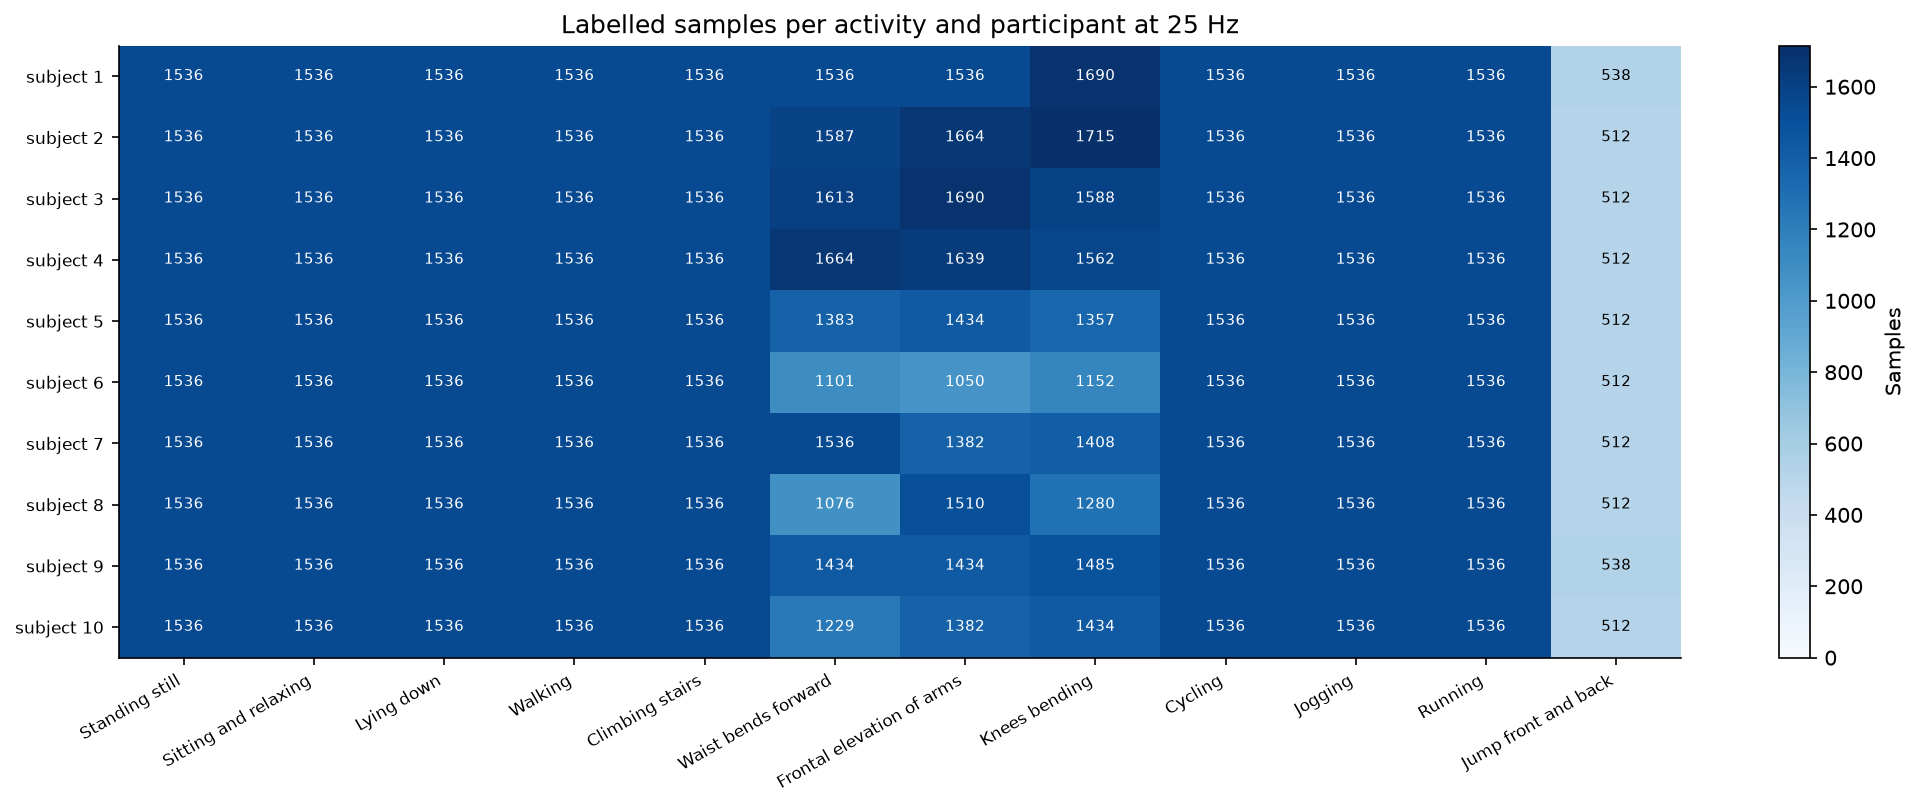

In [5]:
inventoryTable = study.writeInventory(variants)
display(readCsv(study.resultsDirectory / "dataInventory.csv").head(10))
display(Image(filename=study.figuresDirectory / "sampleCounts.png"))

## Rank the window features

A random forest ranks the features by how much they help to tell the activities apart. This ranking uses all windows once and is only for description. The real evaluation ranks the features again inside every training fold, so no test data can influence the choice.

In [6]:
rankingTable = study.rankAllWindows(variants)
display(readCsv(study.resultsDirectory / "selectedFeatures.csv").head(10))

,rank,feature,importance,cumulativeImportance,keptByAllWindowRanking
0,1,leftAnkle_normMean,0.032284,0.032284,True
1,2,leftAnkle_y_variance,0.026419,0.058703,True
2,3,chest_z_mean,0.025443,0.084146,True
3,4,rightLowerArm_y_median,0.023896,0.108043,True
4,5,leftAnkle_z_range,0.023502,0.131545,True
5,6,rightLowerArm_z_rootMeanSquare,0.023214,0.154759,True
6,7,leftAnkle_normVariance,0.023132,0.177891,True
7,8,chest_x_rootMeanSquare,0.022722,0.200613,True
8,9,rightLowerArm_y_rootMeanSquare,0.020381,0.220994,True
9,10,leftAnkle_y_waveletEnergy,0.020161,0.241155,True


## Run every classifier under every protocol

This is the long step. Every classifier is trained and tested fold by fold on several worker processes. Supervised classifiers learn from the labels and run under both protocols. Unsupervised models find groups without labels, the groups are matched to activities afterwards, and they run under the shuffled folds only. Nothing is saved here, the next step scores the results.

In [7]:
foldRecords = study.evaluateAll(variants)
print(f"Fold records: {len(foldRecords)}")

[ COMPARISON : FOLD JOBS ] : 80
Fold records: 240


## Score every fold

Each fold is scored with the accuracy and with the precision, recall, specificity and F measures averaged over the activities. The table keeps one row for every fold and classifier. The confusion counts of the folds are added up for the figures later on.

In [8]:
metricTable, pooledConfusions = study.scoreRecords(variants, foldRecords)
display(readCsv(study.resultsDirectory / "foldMetrics.csv").head(10))

,variant,protocol,fold,classifier,learning,trainRows,testRows,keptFeatures,neighbours,accuracy,...,macroRecall,macroSpecificity,macroF1,attalF,trees,log2Cost,log2Gamma,emIterations,emConverged,converged
0,rawSubsample,shuffledFolds,1,kNearestNeighbour,supervised,15471,1719,NaN,1.0,0.924375,...,0.914528,0.993103,0.917439,0.918313,NaN,NaN,NaN,NaN,NaN,NaN
1,rawSubsample,shuffledFolds,2,kNearestNeighbour,supervised,15471,1719,NaN,1.0,0.919139,...,0.905487,0.992610,0.911880,0.914253,NaN,NaN,NaN,NaN,NaN,NaN
2,rawSubsample,shuffledFolds,3,kNearestNeighbour,supervised,15471,1719,NaN,1.0,0.912740,...,0.899137,0.992036,0.903966,0.905730,NaN,NaN,NaN,NaN,NaN,NaN
3,rawSubsample,shuffledFolds,4,kNearestNeighbour,supervised,15471,1719,NaN,1.0,0.913903,...,0.896122,0.992137,0.902173,0.905469,NaN,NaN,NaN,NaN,NaN,NaN
4,rawSubsample,shuffledFolds,5,kNearestNeighbour,supervised,15471,1719,NaN,1.0,0.913903,...,0.905044,0.992153,0.907463,0.908580,NaN,NaN,NaN,NaN,NaN,NaN
5,rawSubsample,shuffledFolds,6,kNearestNeighbour,supervised,15471,1719,NaN,1.0,0.925538,...,0.916103,0.993198,0.920747,0.922190,NaN,NaN,NaN,NaN,NaN,NaN
6,rawSubsample,shuffledFolds,7,kNearestNeighbour,supervised,15471,1719,NaN,1.0,0.927283,...,0.914587,0.993360,0.919738,0.921315,NaN,NaN,NaN,NaN,NaN,NaN
7,rawSubsample,shuffledFolds,8,kNearestNeighbour,supervised,15471,1719,NaN,1.0,0.914485,...,0.902636,0.992194,0.907097,0.908790,NaN,NaN,NaN,NaN,NaN,NaN
8,rawSubsample,shuffledFolds,9,kNearestNeighbour,supervised,15471,1719,NaN,1.0,0.915649,...,0.900476,0.992296,0.906494,0.909312,NaN,NaN,NaN,NaN,NaN,NaN
9,rawSubsample,shuffledFolds,10,kNearestNeighbour,supervised,15471,1719,NaN,1.0,0.922048,...,0.905162,0.992889,0.910261,0.912969,NaN,NaN,NaN,NaN,NaN,NaN


## Average over the folds

The fold scores are averaged for each variant, protocol and classifier. The standard deviation over the folds tells you how stable a score is.

In [9]:
summaryTable = study.summariseMetrics(metricTable)
display(readCsv(study.resultsDirectory / "metricSummary.csv").head(10))

,variant,protocol,learning,classifier,folds,accuracy,accuracyStd,attalF,macroRecall,macroPrecision,macroSpecificity,macroF1,macroF1Std
0,rawSubsample,shuffledFolds,supervised,kNearestNeighbour,10,0.918906,0.005500,0.912692,0.905928,0.919566,0.992598,0.910726,0.006573
1,rawSubsample,shuffledFolds,supervised,randomForest,10,0.913554,0.006350,0.907674,0.898213,0.917358,0.992102,0.904379,0.006978
2,rawSubsample,shuffledFolds,supervised,supportVectorMachine,10,0.903083,0.010568,0.898199,0.893756,0.902696,0.991157,0.896898,0.012337
3,rawSubsample,shuffledFolds,supervised,supervisedLearningGaussianMixture,10,0.762420,0.006444,0.742703,0.734579,0.751025,0.978319,0.734211,0.009264
4,rawSubsample,leaveOneSubjectOut,supervised,kNearestNeighbour,10,0.653968,0.064681,0.641854,0.648158,0.635835,0.968441,0.622206,0.063255
5,rawSubsample,leaveOneSubjectOut,supervised,randomForest,10,0.689764,0.080530,0.669968,0.682994,0.658719,0.971745,0.649365,0.092642
6,rawSubsample,leaveOneSubjectOut,supervised,supportVectorMachine,10,0.712604,0.074697,0.705583,0.707925,0.704227,0.973800,0.687850,0.082412
7,rawSubsample,leaveOneSubjectOut,supervised,supervisedLearningGaussianMixture,10,0.708071,0.064949,0.690793,0.681396,0.700861,0.973391,0.670430,0.065826
8,rawFull,shuffledFolds,supervised,kNearestNeighbour,10,0.954436,0.001853,0.950527,0.945437,0.955675,0.995839,0.949596,0.001792
9,rawFull,shuffledFolds,unsupervised,hiddenMarkovModel,10,0.466332,0.034963,0.442575,0.466204,0.422347,0.951391,0.398025,0.041254


## Write down the values of the paper

The paper prints its scores in tables. This step puts those values into one table, so they can be set next to ours. The F measure is recomputed from the printed recall and precision, as a check that the values were read correctly.

In [10]:
referenceTable = study.buildPaperReference()
display(readCsv(study.resultsDirectory / "paperReference.csv").head(10))

,table,variant,learning,classifier,paperAccuracy,paperAccuracyStd,paperF,paperRecall,paperPrecision,paperSpecificity,source,fFromPrintedRecallPrecision,fMatchesWithinRounding
0,3,rawSubsample,supervised,kNearestNeighbour,96.53,0.20,94.60,94.57,94.62,99.67,"Attal et al. (2015), Sensors 15(12), full text...",94.594993,True
1,3,rawSubsample,supervised,randomForest,94.89,0.57,82.87,82.28,83.46,99.43,"Attal et al. (2015), Sensors 15(12), full text...",82.865799,True
2,3,rawSubsample,supervised,supportVectorMachine,94.22,0.28,90.66,90.98,90.33,99.56,"Attal et al. (2015), Sensors 15(12), full text...",90.653835,True
3,3,rawSubsample,supervised,supervisedLearningGaussianMixture,84.54,0.30,69.94,69.99,69.88,98.39,"Attal et al. (2015), Sensors 15(12), full text...",69.934957,True
4,4,rawFull,unsupervised,hiddenMarkovModel,80.00,2.10,67.67,65.02,66.15,97.68,"Attal et al. (2015), Sensors 15(12), full text...",65.580133,False
5,4,rawFull,unsupervised,kMeans,68.42,5.05,49.89,48.67,48.55,93.21,"Attal et al. (2015), Sensors 15(12), full text...",48.609926,False
6,4,rawFull,unsupervised,gaussianMixture,73.60,2.32,57.68,57.54,58.82,96.45,"Attal et al. (2015), Sensors 15(12), full text...",58.172960,False
7,7,features80,supervised,kNearestNeighbour,99.25,0.17,98.85,98.85,98.85,99.96,"Attal et al. (2015), Sensors 15(12), full text...",98.850000,True
8,7,features80,supervised,randomForest,98.95,0.09,98.27,98.24,98.25,99.90,"Attal et al. (2015), Sensors 15(12), full text...",98.245000,False
9,7,features80,supervised,supportVectorMachine,95.55,0.30,93.02,93.15,92.90,99.92,"Attal et al. (2015), Sensors 15(12), full text...",93.024832,True


## Compare with the paper

Our shuffled fold results are placed next to the printed values, with the difference for every score. The figure shows our accuracy beside the paper's accuracy for each table. Differences are expected, because the data and the sensor placements are not the same.

,table,variant,learning,classifier,paperAccuracy,paperAccuracyStd,paperF,paperRecall,paperPrecision,paperSpecificity,...,ourAccuracyStd,differenceAccuracyStd,ourAttalF,differenceAttalF,ourMacroRecall,differenceMacroRecall,ourMacroPrecision,differenceMacroPrecision,ourMacroSpecificity,differenceMacroSpecificity
0,3,rawSubsample,supervised,kNearestNeighbour,96.53,0.20,94.60,94.57,94.62,99.67,...,0.549970,0.349970,91.269208,-3.330792,90.592823,-3.977177,91.956610,-2.663390,99.259767,-0.410233
1,3,rawSubsample,supervised,randomForest,94.89,0.57,82.87,82.28,83.46,99.43,...,0.635011,0.065011,90.767431,7.897431,89.821279,7.541279,91.735771,8.275771,99.210237,-0.219763
2,3,rawSubsample,supervised,supportVectorMachine,94.22,0.28,90.66,90.98,90.33,99.56,...,1.056843,0.776843,89.819863,-0.840137,89.375597,-1.604403,90.269557,-0.060443,99.115657,-0.444343
3,3,rawSubsample,supervised,supervisedLearningGaussianMixture,84.54,0.30,69.94,69.99,69.88,98.39,...,0.644416,0.344416,74.270307,4.330307,73.457935,3.467935,75.102477,5.222477,97.831908,-0.558092
4,4,rawFull,unsupervised,hiddenMarkovModel,80.00,2.10,67.67,65.02,66.15,97.68,...,3.496268,1.396268,44.257470,-23.412530,46.620421,-18.399579,42.234668,-23.915332,95.139057,-2.540943
5,4,rawFull,unsupervised,kMeans,68.42,5.05,49.89,48.67,48.55,93.21,...,2.059947,-2.990053,44.626438,-5.263562,44.867245,-3.802755,44.400689,-4.149311,95.128398,1.918398
6,4,rawFull,unsupervised,gaussianMixture,73.60,2.32,57.68,57.54,58.82,96.45,...,3.659305,1.339305,48.837389,-8.842611,50.143380,-7.396620,47.680409,-11.139591,95.586186,-0.863814
7,7,features80,supervised,kNearestNeighbour,99.25,0.17,98.85,98.85,98.85,99.96,...,0.086043,-0.083957,99.663368,0.813368,99.662965,0.812965,99.663771,0.813771,99.967545,0.007545
8,7,features80,supervised,randomForest,98.95,0.09,98.27,98.24,98.25,99.90,...,0.117134,0.027134,99.543180,1.273180,99.540122,1.300122,99.546242,1.296242,99.957047,0.057047
9,7,features80,supervised,supportVectorMachine,95.55,0.30,93.02,93.15,92.90,99.92,...,0.134161,-0.165839,99.740654,6.720654,99.741029,6.591029,99.740280,6.840280,99.975438,0.055438


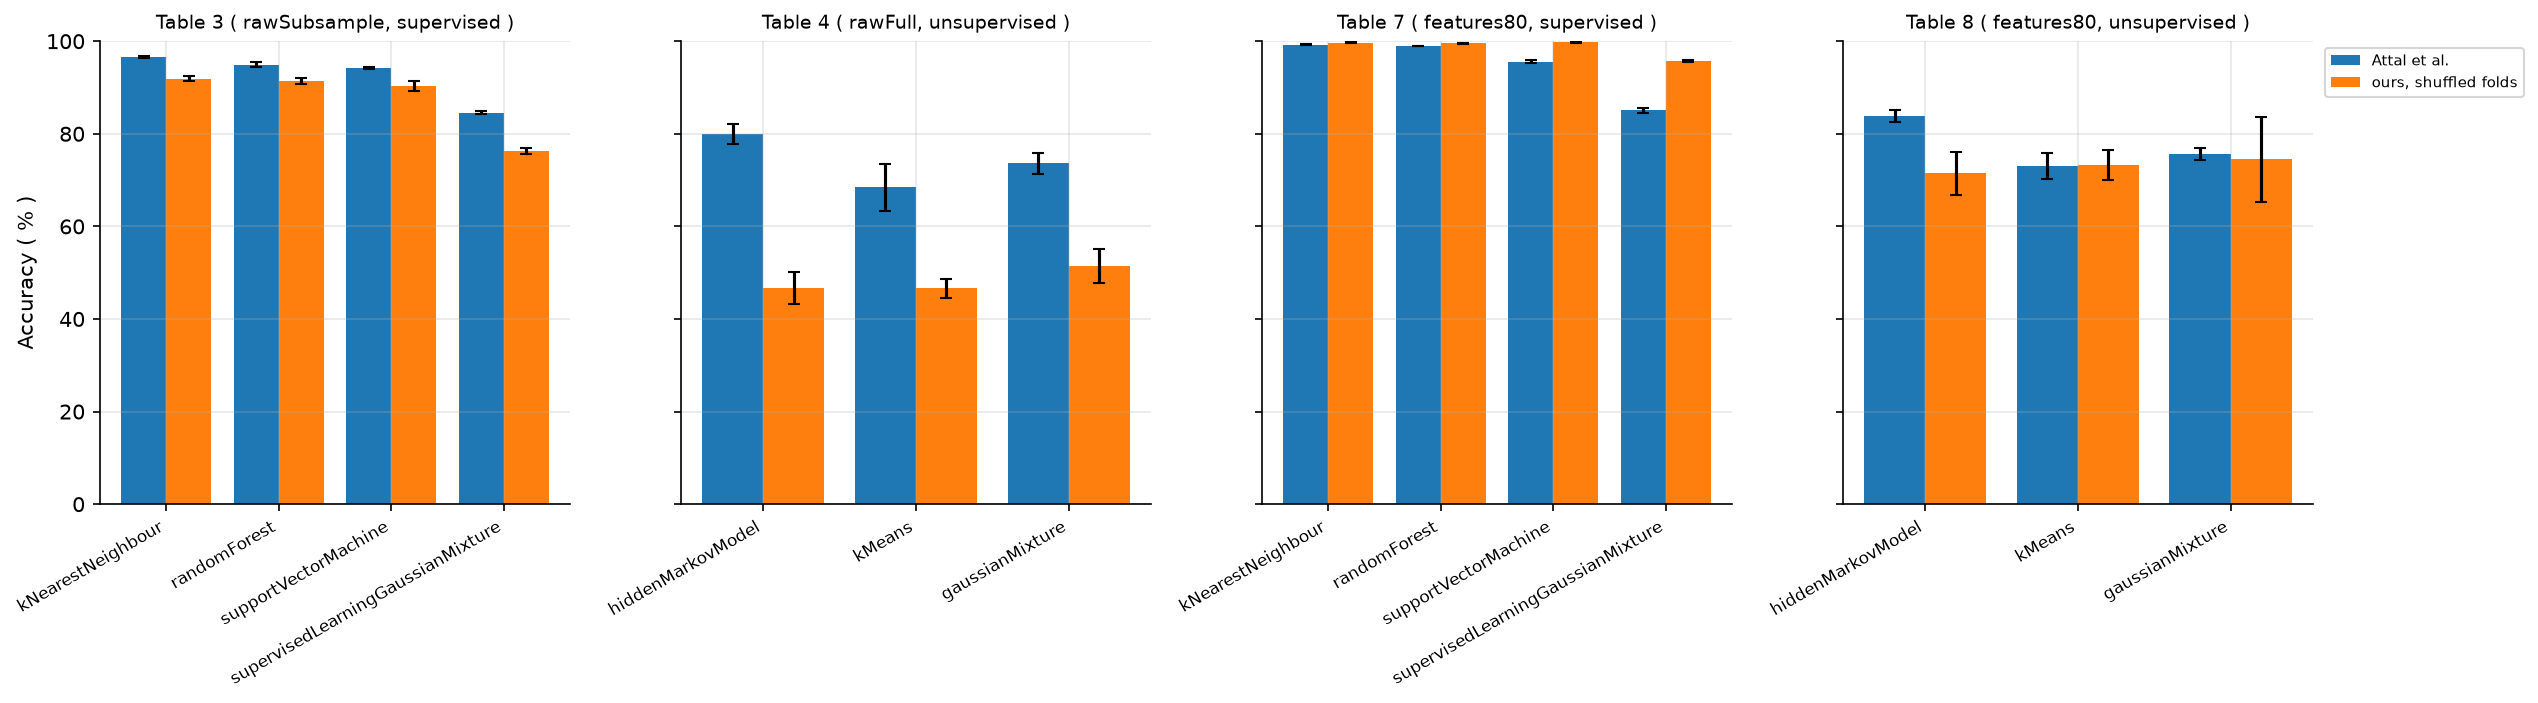

In [11]:
comparisonTable = study.compareWithPaper(summaryTable, referenceTable)
display(readCsv(study.resultsDirectory / "attalComparison.csv").head(10))
display(Image(filename=study.figuresDirectory / "attalComparison.png"))

## Compare the two protocols

Shuffled folds put rows of the same participant into both the training set and the test set. Leave one participant out tests on a person the classifier has never seen. The table and the figure show how much the scores fall from the first protocol to the second.

,variant,classifier,accuracy_shuffledFolds,accuracyStd_shuffledFolds,macroF1_shuffledFolds,macroF1Std_shuffledFolds,accuracy_leaveOneSubjectOut,accuracyStd_leaveOneSubjectOut,macroF1_leaveOneSubjectOut,macroF1Std_leaveOneSubjectOut,accuracyDropPoints_leaveOneSubjectOut,macroF1DropPoints_leaveOneSubjectOut
0,rawSubsample,kNearestNeighbour,0.918906,0.005500,0.910726,0.006573,0.653968,0.064681,0.622206,0.063255,26.493837,28.851954
1,rawSubsample,randomForest,0.913554,0.006350,0.904379,0.006978,0.689764,0.080530,0.649365,0.092642,22.379041,25.501459
2,rawSubsample,supportVectorMachine,0.903083,0.010568,0.896898,0.012337,0.712604,0.074697,0.687850,0.082412,19.047877,20.904829
3,rawSubsample,supervisedLearningGaussianMixture,0.762420,0.006444,0.734211,0.009264,0.708071,0.064949,0.670430,0.065826,5.434925,6.378173
4,rawFull,kNearestNeighbour,0.954436,0.001853,0.949596,0.001792,0.654100,0.061663,0.618683,0.063149,30.033562,33.091280
5,features80,kNearestNeighbour,0.996448,0.000860,0.996628,0.000834,0.918579,0.048432,0.906074,0.058510,7.786848,9.055457
6,features80,randomForest,0.995293,0.001171,0.995419,0.001166,0.948204,0.051285,0.942547,0.061363,4.708894,5.287204
7,features80,supportVectorMachine,0.997306,0.001342,0.997399,0.001284,0.944525,0.047658,0.937072,0.058172,5.278096,6.032745
8,features80,supervisedLearningGaussianMixture,0.957611,0.002637,0.958901,0.002567,0.930959,0.038385,0.927513,0.045300,2.665138,3.138768


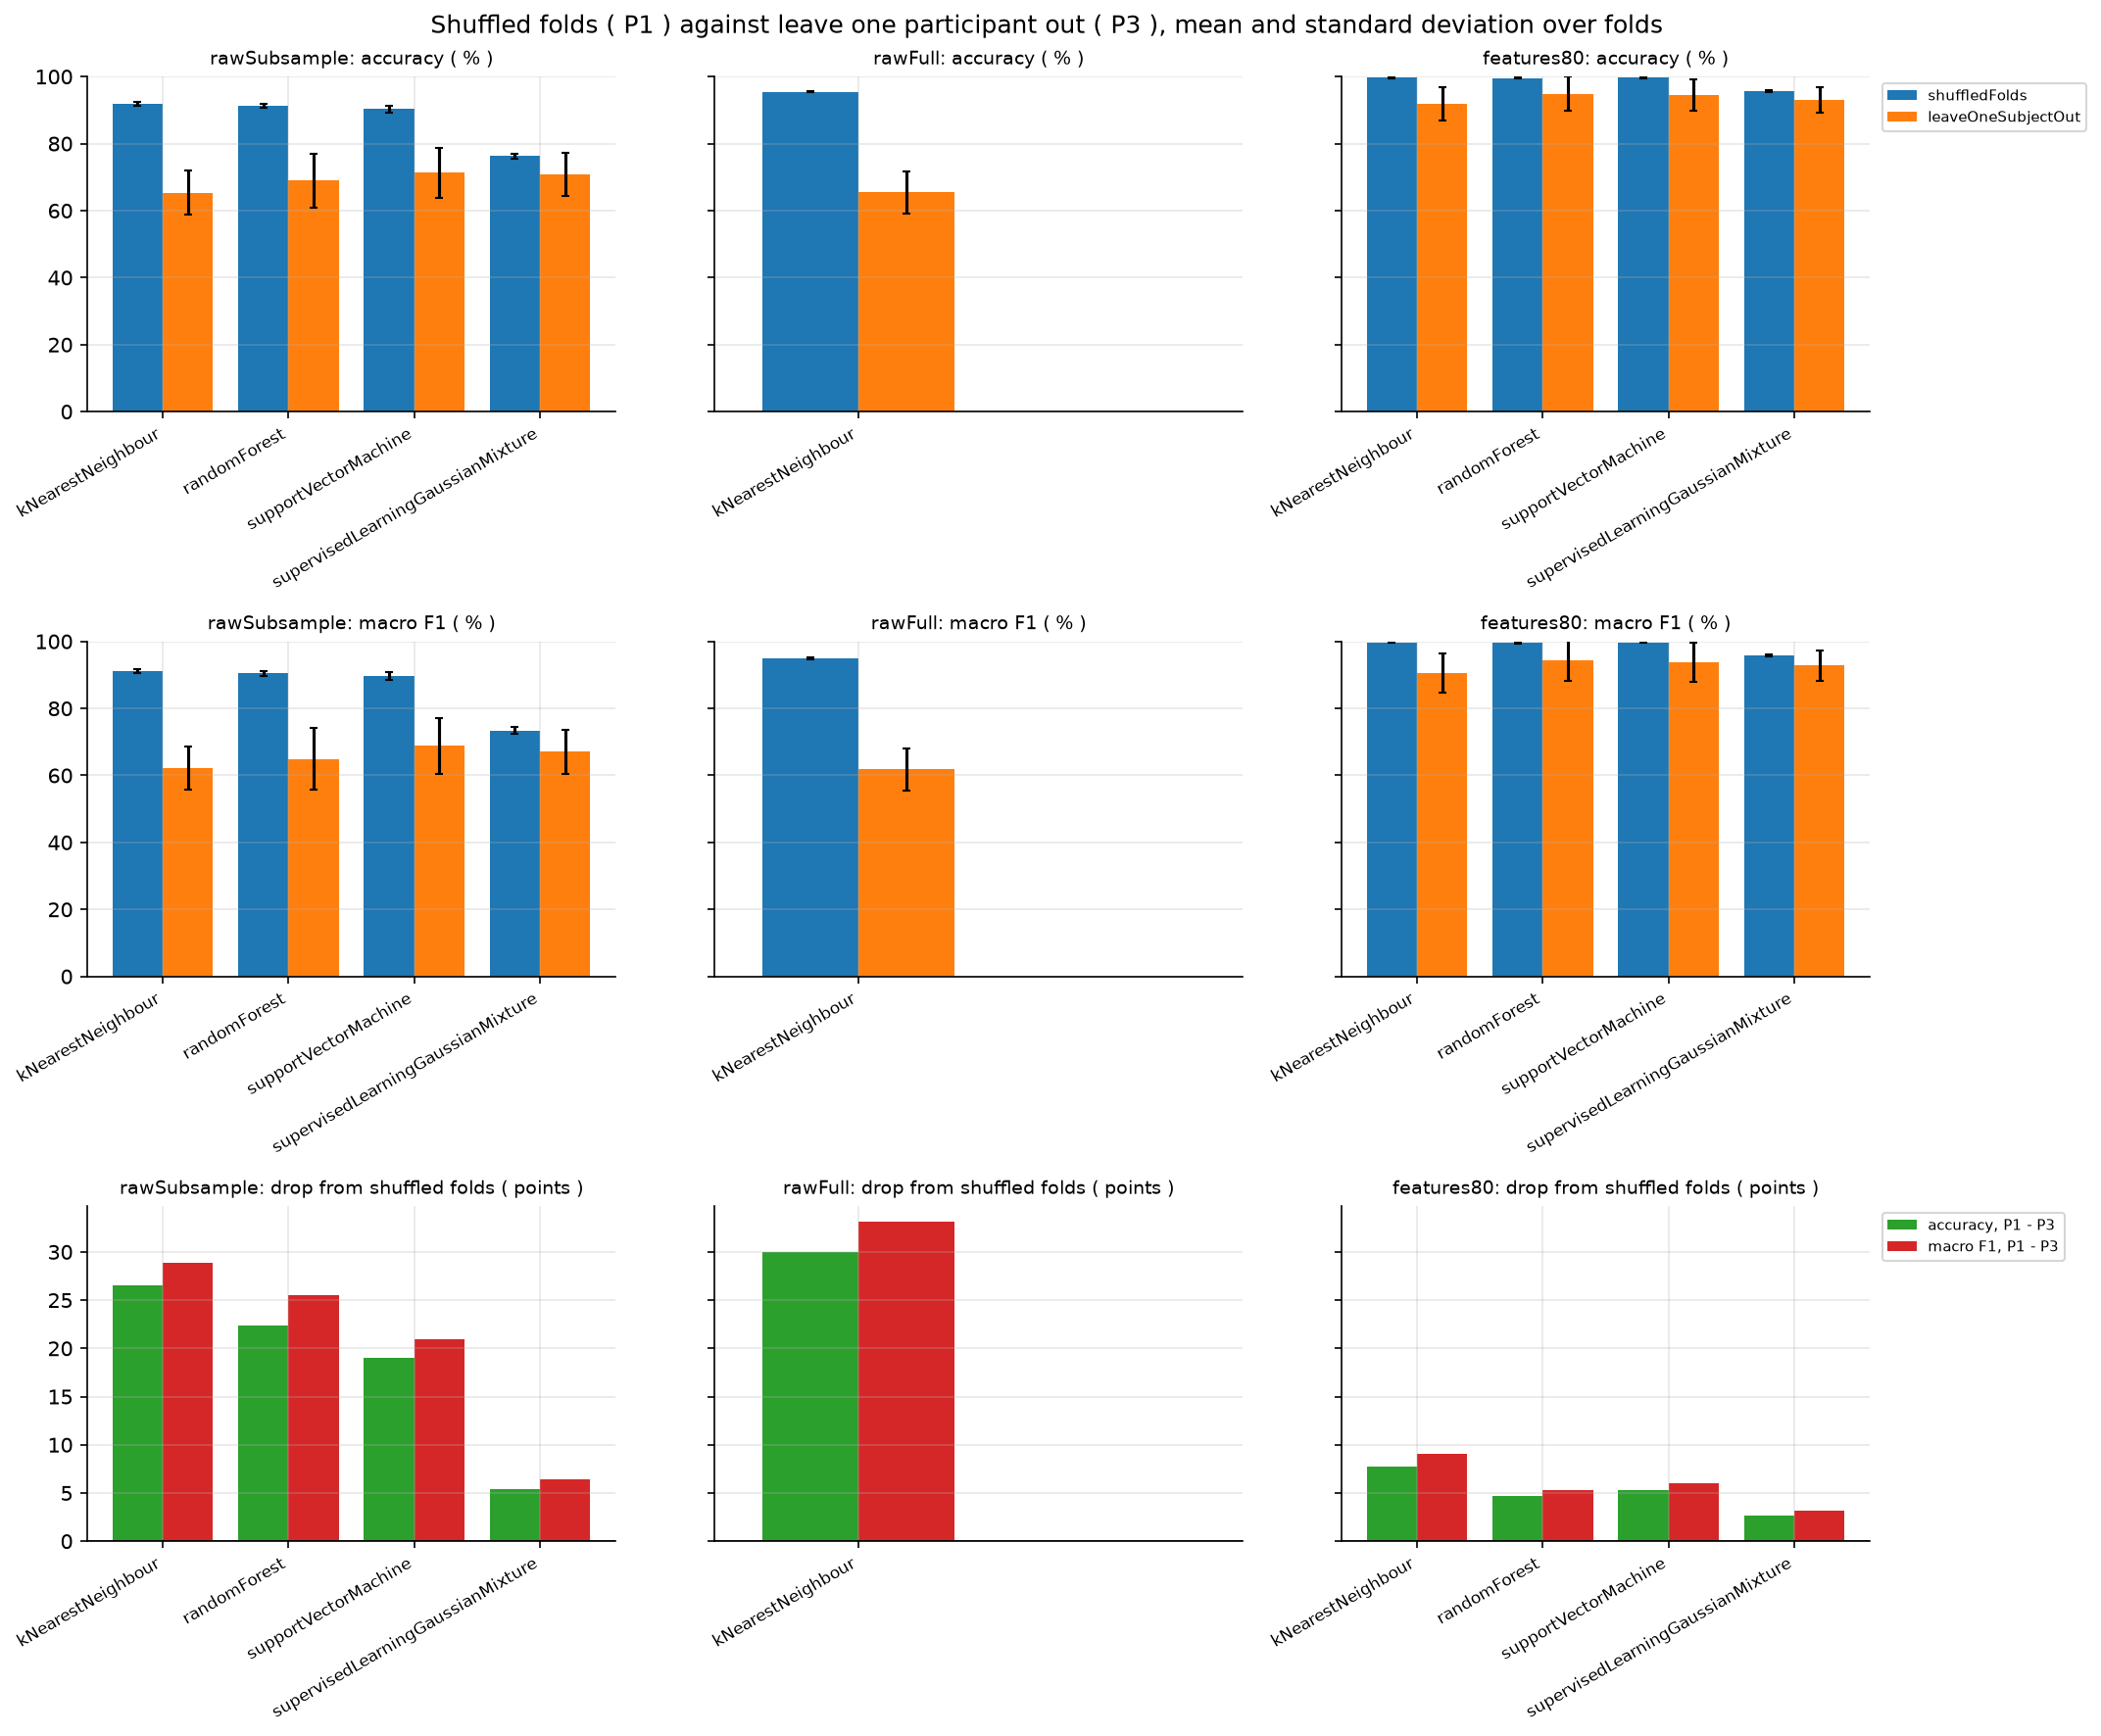

In [12]:
protocolTable = study.compareProtocols(summaryTable)
display(readCsv(study.resultsDirectory / "protocolComparison.csv").head(10))
display(Image(filename=study.figuresDirectory / "protocolComparison.png"))

## Look at the confusions

A confusion matrix shows which activities get mixed up. This step adds up the shuffled fold results of k-NN and of the hidden Markov model and draws them as the paper does. Each row shows where the rows of one true activity were sent.

,variant,classifier,paperTable,trueClass,predictedClass,rows
0,rawSubsample,kNearestNeighbour,5,Standing still,Standing still,1538
1,rawSubsample,kNearestNeighbour,5,Standing still,Sitting and relaxing,0
2,rawSubsample,kNearestNeighbour,5,Standing still,Lying down,0
3,rawSubsample,kNearestNeighbour,5,Standing still,Walking,0
4,rawSubsample,kNearestNeighbour,5,Standing still,Climbing stairs,0
5,rawSubsample,kNearestNeighbour,5,Standing still,Waist bends forward,2
6,rawSubsample,kNearestNeighbour,5,Standing still,Frontal elevation of arms,0
7,rawSubsample,kNearestNeighbour,5,Standing still,Knees bending,0
8,rawSubsample,kNearestNeighbour,5,Standing still,Cycling,0
9,rawSubsample,kNearestNeighbour,5,Standing still,Jogging,0


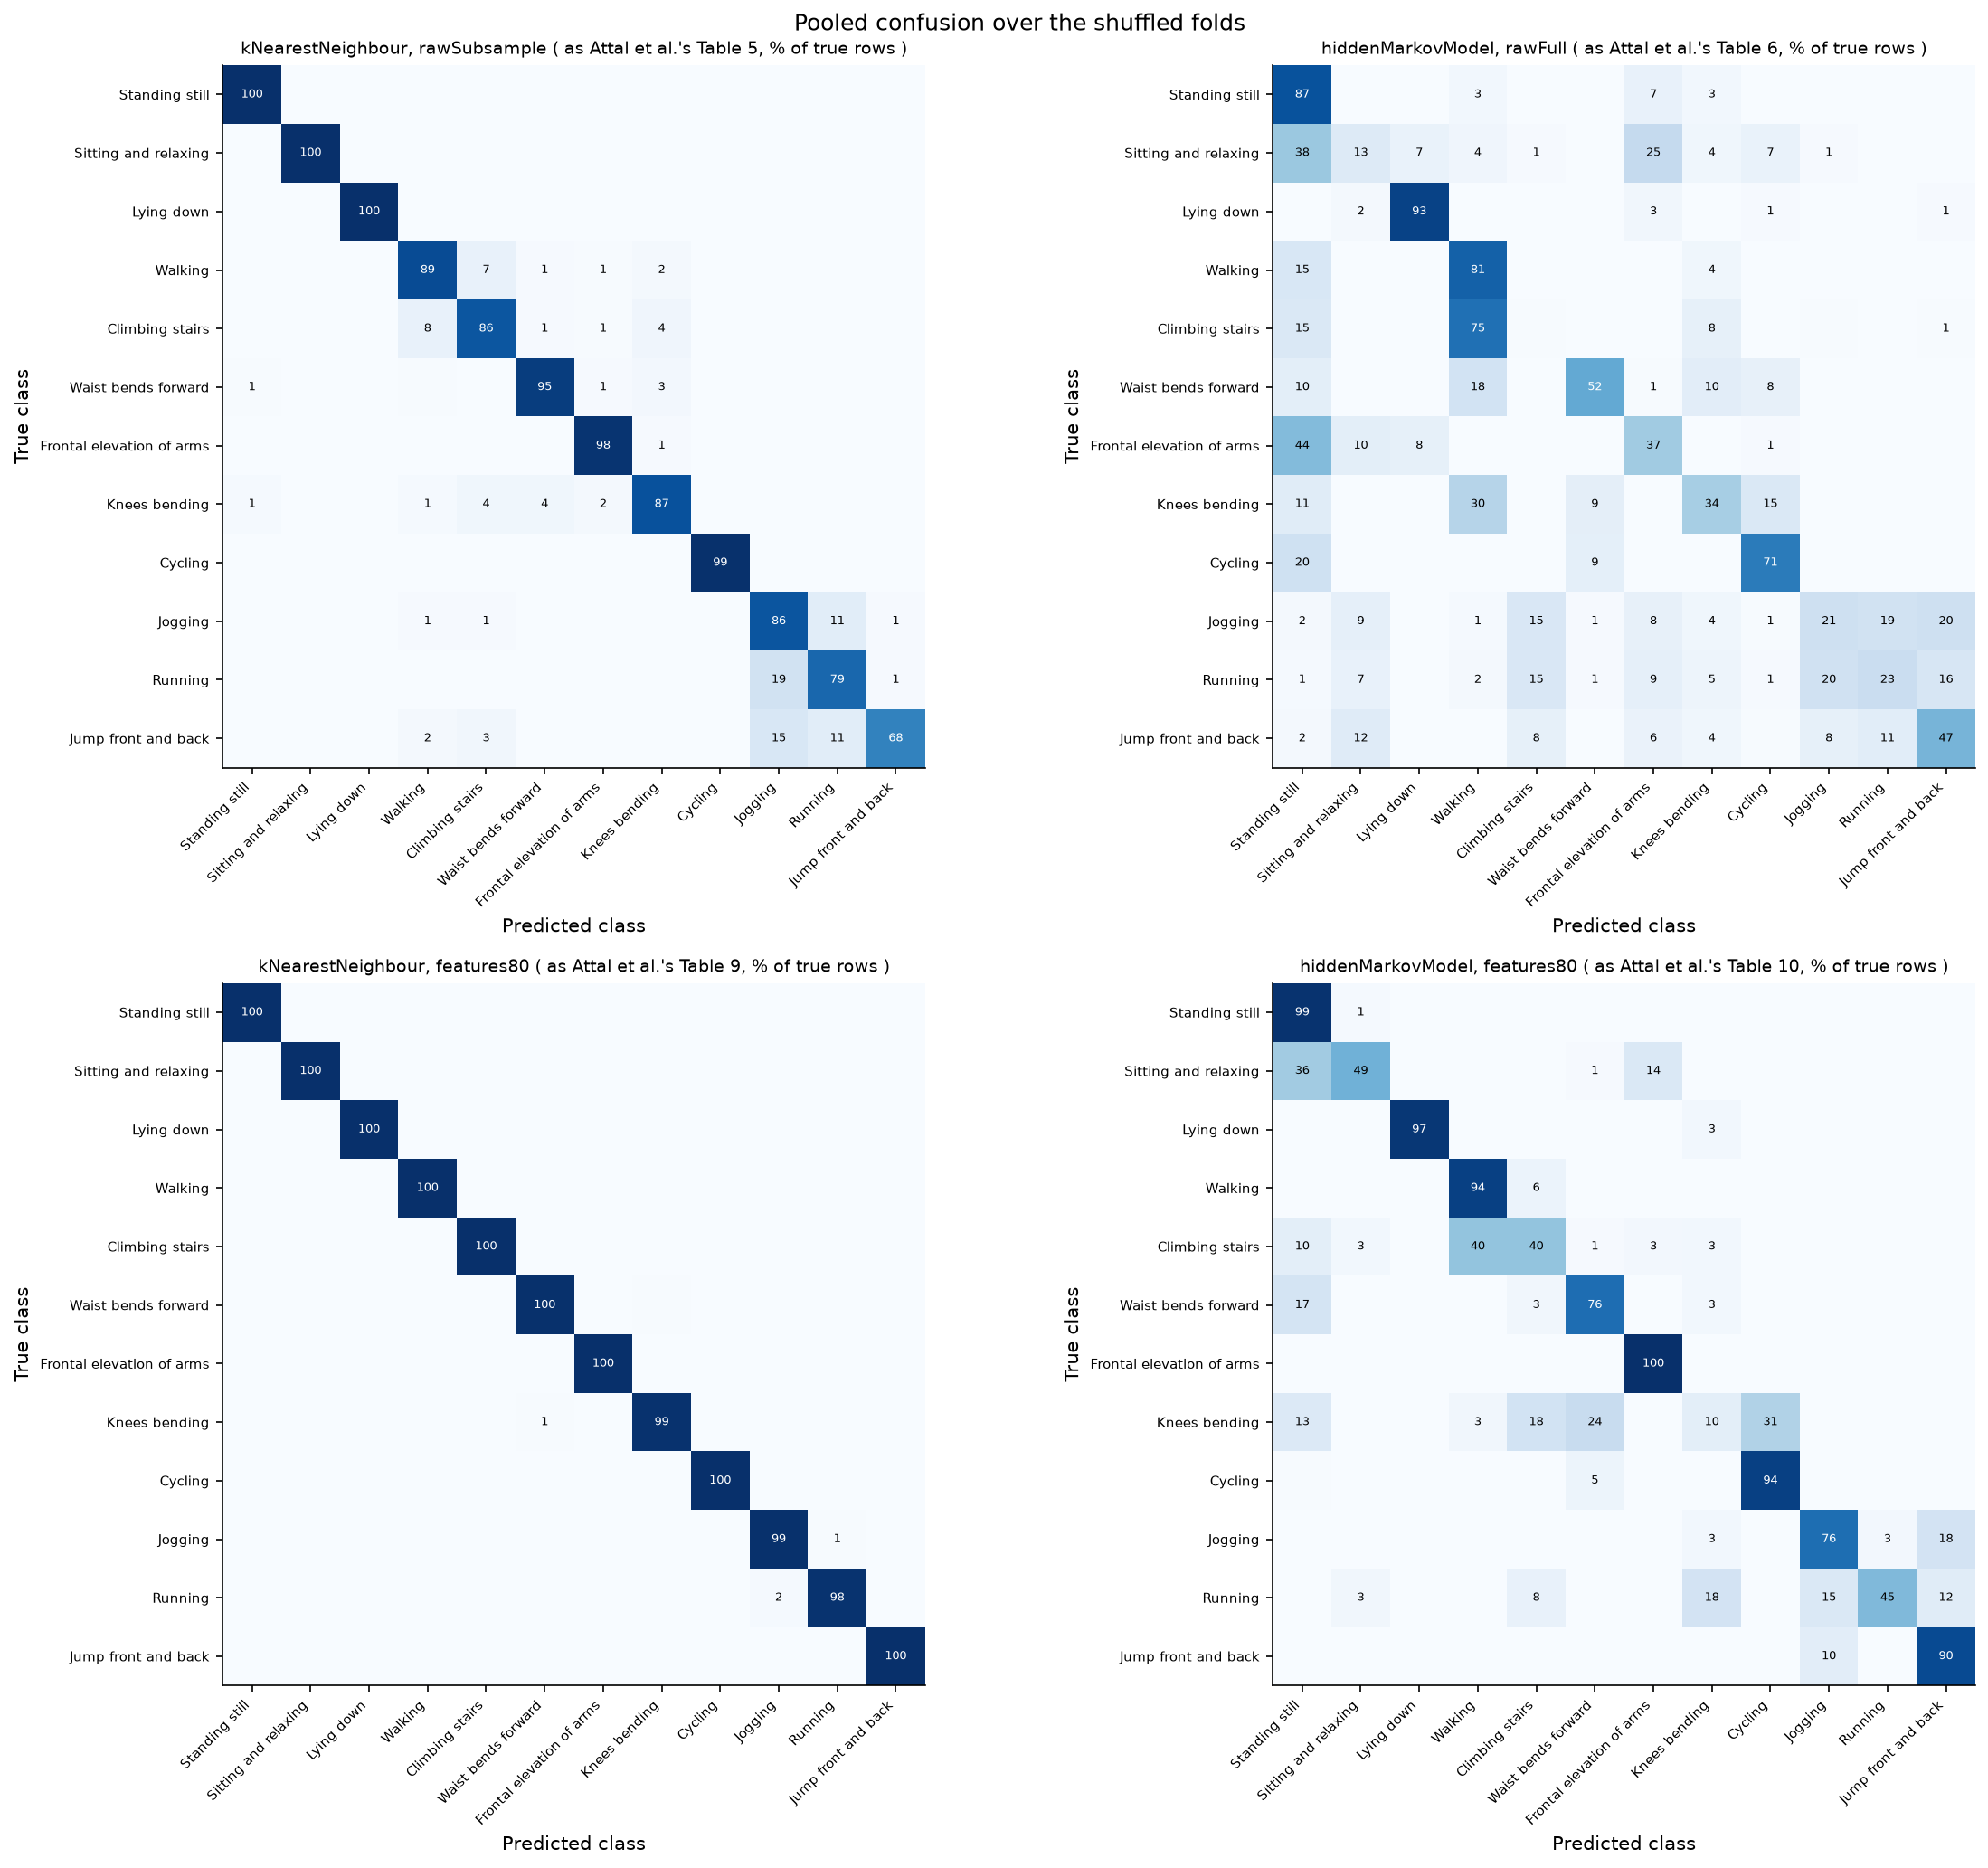

In [13]:
confusionTable = study.plotConfusions(pooledConfusions)
display(readCsv(study.resultsDirectory / "confusionMatrices.csv").head(10))
display(Image(filename=study.figuresDirectory / "confusionMatrices.png"))

## Record the parameters

Every setting, definition and library version of the run is written to one table.

In [14]:
parameterTable = study.writeParameters(variants)
display(readCsv(study.resultsDirectory / "runParameters.csv").head(10))

,section,parameter,value
0,run,randomSeed,42
1,run,nJobs,4
2,run,python,3.12.14
3,run,numpy,2.5.3
4,run,pandas,3.0.6
5,run,scipy,1.18.1
6,run,scikit-learn,1.9.1
7,run,hmmlearn,0.3.3
8,run,matplotlib,3.11.2
9,data,subjects,10
